#### 1) Importing Necessary Libraries:

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

#### 2) Loading Data:

In [2]:
df = pd.read_csv('shopping_data.csv')

In [3]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.shape

(200, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


- Our dataset has five columns: CustomerID, Genre, Age, Annual Income, and Spending Score. 

- To view the results in two-dimensional feature space, we will retain only two of these five columns. We can remove CustomerID column, Genre, and Age column.

- We will retain the Annual Income (in thousands of dollars) and Spending Score (1-100) columns.

- The Spending Score column signifies how often a person spends money in a mall on a scale of 1 to 100 with 100 being the highest spender.

In [7]:
df.drop(['CustomerID', 'Age', 'Genre'], axis= 1, inplace= True)

In [8]:
df.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


#### 3) Exploring and Transforming Data:

##### 1) Annual Income (k$):

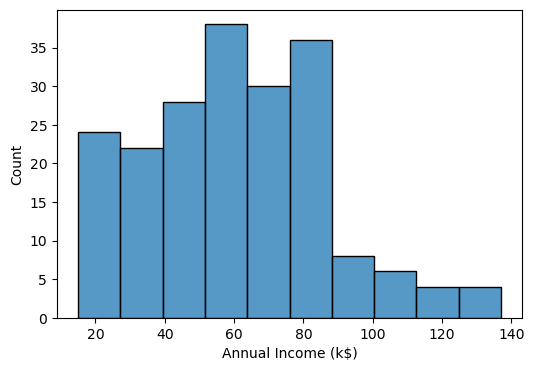

In [9]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'Annual Income (k$)')
plt.show()

##### 2) Spending Score (1-100):

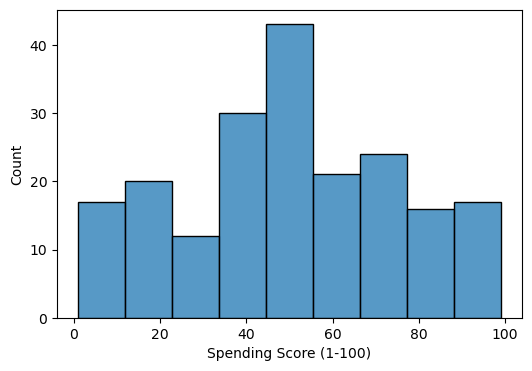

In [10]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'Spending Score (1-100)')
plt.show()

##### 3) Relationship Between Features:

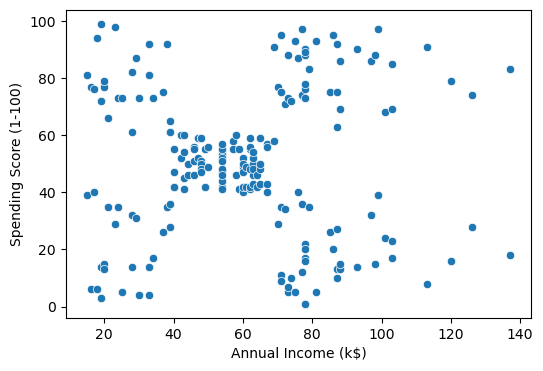

In [11]:
plt.figure(figsize= (6,4))
sns.scatterplot(data= df, x= 'Annual Income (k$)', y= 'Spending Score (1-100)')
plt.show()

##### 4) Scaling the Features:

In [12]:
sc = StandardScaler()
temp = sc.fit_transform(df)
scaled_df = pd.DataFrame(data= temp, columns= df.columns)
scaled_df.head()

,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


#### 4) Finding Optimal Number of Clusters using Inertia and Silhouette Score:

In [15]:
inertia = []
sil_score = []

for num in range(2, 11):
    kmc = KMeans(n_clusters= num) # KMeans Intance
    clusters = kmc.fit_predict(scaled_df) #Fitting and Predicting CLuster for Data Points
    inertia.append(kmc.inertia_)
    sil_score.append(silhouette_score(X= scaled_df, labels= clusters))

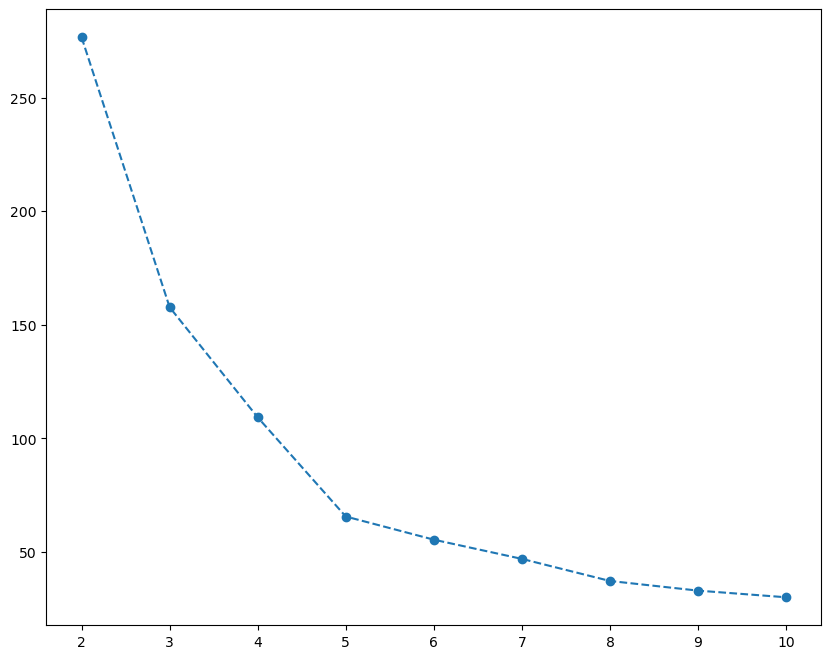

In [16]:
# Plotting Cluster Inertia:

plt.figure(figsize= (10, 8))
plt.plot(range(2, 11), inertia, 'o--')
plt.show()

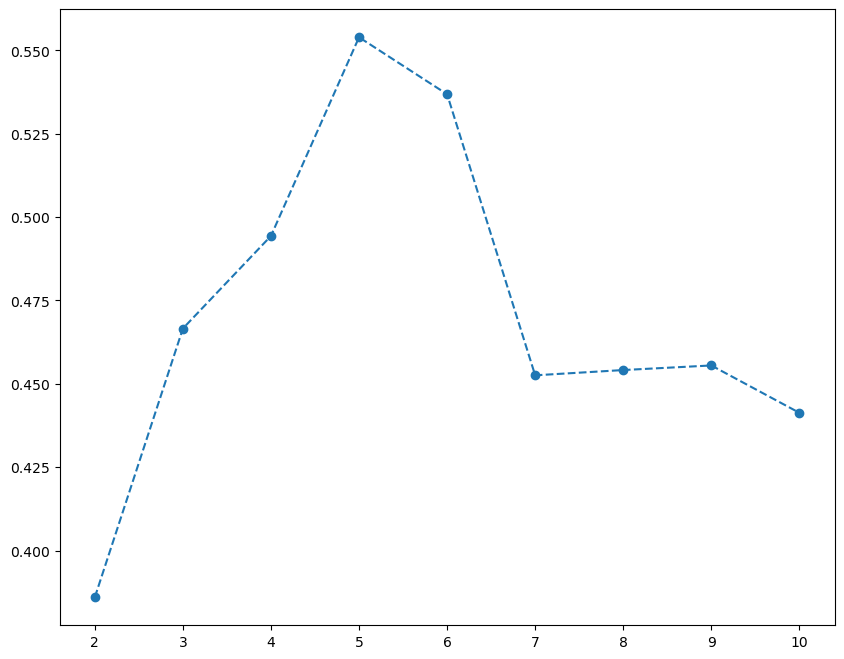

In [17]:
# Plotting Silhouette Score:

plt.figure(figsize= (10, 8))
plt.plot(range(2, 11), sil_score, 'o--')
plt.show()

- Considering both Inertia and Silhouette Score, 5 seems to be Optimal Number of Clusters for this Dataset.

#### 5) Clustering:

In [19]:
kmc = KMeans(n_clusters= 5) #KMeans with 5 Clusters
clusters = kmc.fit_predict(scaled_df) #Fitting on data and predicting Cluster for each datapoint
scaled_df['Clusters'] = clusters #Attaching cluster numbers as a column to dataset
scaled_df.head()

,Annual Income (k$),Spending Score (1-100),Clusters
0,-1.738999,-0.434801,3
1,-1.738999,1.195704,4
2,-1.700830,-1.715913,3
3,-1.700830,1.040418,4
4,-1.662660,-0.395980,3


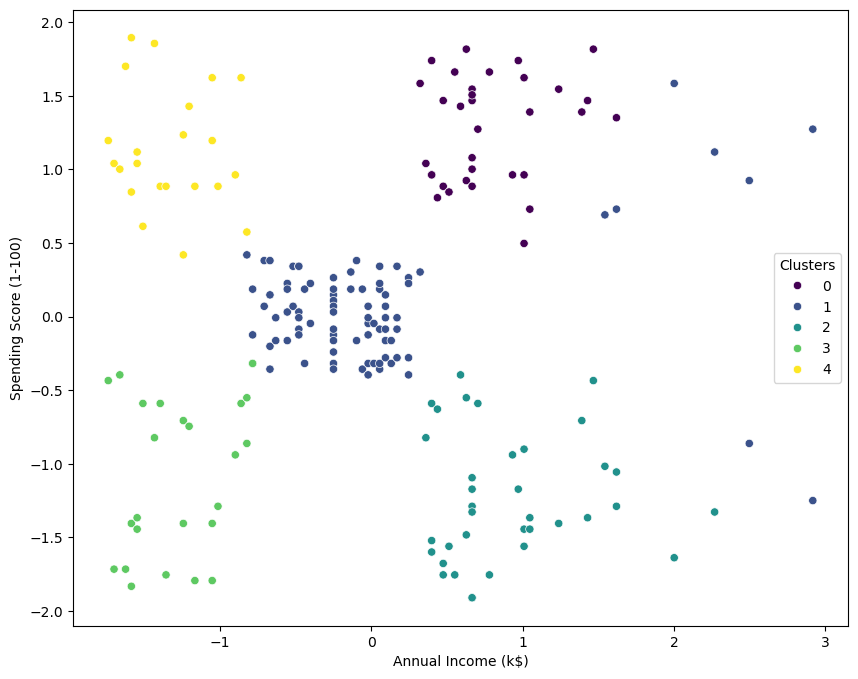

In [23]:
# Visualizing Clusters:

plt.figure(figsize= (10,8))
sns.scatterplot(data= scaled_df, x= 'Annual Income (k$)', y= 'Spending Score (1-100)', hue= 'Clusters', palette= 'viridis')
plt.show()